# Total recall

How many unique clips do participants recall, and does this differ by task, condition, or intervention?

Total recall is the most basic measure of retrieval success and the headline DV for the selective interference effect. Each trial yields a scalar (0–11 unique clips recalled). We also break down total recall into spontaneous vs cue-driven recalls to see whether experimental factors differentially affect retrieval that was prompted by a film cue versus retrieval that occurred without one.

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.helpers import find_project_root, load_data
from jaxcmr.selective_interference.analysis import derive_cue_clips

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_total_recall"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

task = np.array(data["task"]).reshape(-1)
condition = np.array(data["condition"]).reshape(-1)
intervention = np.array(data["intervention"]).reshape(-1)
recalls = np.array(data["recalls"])

cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    recalls,
)

n_trials = recalls.shape[0]
print(f"Loaded {n_trials} trials")

Loaded 240 trials


## Computing total recall and its components

For each trial, total recall is the count of non-zero entries in the unique-first `recalls` array. We split this into cue-driven recalls (where the cue clip number matches the recalled clip) and spontaneous recalls (everything else — no cue, or cue didn't match).

In [4]:
total = (recalls > 0).sum(axis=1)
cue_driven = ((cue_clips == recalls) & (cue_clips > 0)).sum(axis=1)
spontaneous = total - cue_driven

print(f"Mean total recall: {total.mean():.2f} (SD={total.std():.2f})")
print(f"Mean cue-driven:   {cue_driven.mean():.2f} (SD={cue_driven.std():.2f})")
print(f"Mean spontaneous:  {spontaneous.mean():.2f} (SD={spontaneous.std():.2f})")

Mean total recall: 8.40 (SD=2.63)
Mean cue-driven:   3.71 (SD=2.99)
Mean spontaneous:  4.69 (SD=3.56)


## Plotting helpers

A bar chart with 95% CI error bars, computed from per-subject means. Each condition gets a group of bars; when `breakdown=True`, each bar is split into spontaneous (bottom) and cue-driven (top) stacked components.

In [5]:
def subject_means(values, mask, subjects):
    """Compute per-subject mean of `values` within `mask`."""
    unique_subs = np.unique(subjects[mask])
    means = []
    for s in unique_subs:
        sub_mask = mask & (subjects == s)
        if sub_mask.sum() > 0:
            means.append(values[sub_mask].mean())
    return np.array(means)


def ci95(values):
    """Return (mean, lower_err, upper_err) for 95% CI."""
    m = values.mean()
    se = values.std(ddof=1) / np.sqrt(len(values))
    return m, 1.96 * se


subjects = np.array(data["subject"]).reshape(-1)


def plot_total_recall(masks, labels, contrast_name, breakdown=False, ax=None):
    """Bar chart of total recall by condition, optionally stacked."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    x = np.arange(len(labels))
    width = 0.6

    if breakdown:
        for i, (mask, label) in enumerate(zip(masks, labels)):
            sm_spont = subject_means(spontaneous, mask, subjects)
            sm_cued = subject_means(cue_driven, mask, subjects)
            m_spont, e_spont = ci95(sm_spont)
            m_cued, e_cued = ci95(sm_cued)
            ax.bar(x[i], m_spont, width, color="steelblue",
                   label="Spontaneous" if i == 0 else None)
            ax.bar(x[i], m_cued, width, bottom=m_spont, color="coral",
                   label="Cue-driven" if i == 0 else None)
            ax.errorbar(x[i], m_spont + m_cued, yerr=ci95(sm_spont + sm_cued)[1],
                        fmt="none", color="black", capsize=4)
            n = int(mask.sum())
            print(f"{label}: n={n}, total={m_spont+m_cued:.2f}, "
                  f"spont={m_spont:.2f}, cued={m_cued:.2f}")
        ax.legend()
    else:
        for i, (mask, label) in enumerate(zip(masks, labels)):
            sm = subject_means(total, mask, subjects)
            m, e = ci95(sm)
            ax.bar(x[i], m, width, yerr=e, color="steelblue",
                   capsize=4, error_kw={"color": "black"})
            n = int(mask.sum())
            print(f"{label}: n={n}, mean={m:.2f} +/- {e:.2f}")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Total unique clips recalled")
    ax.set_title(contrast_name)
    return ax


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

## Task (involuntary vs voluntary)

Involuntary: n=120, mean=7.05 +/- 0.49
Voluntary: n=120, mean=9.76 +/- 0.29
Involuntary: n=120, total=7.05, spont=2.66, cued=4.39
Voluntary: n=120, total=9.76, spont=6.72, cued=3.03


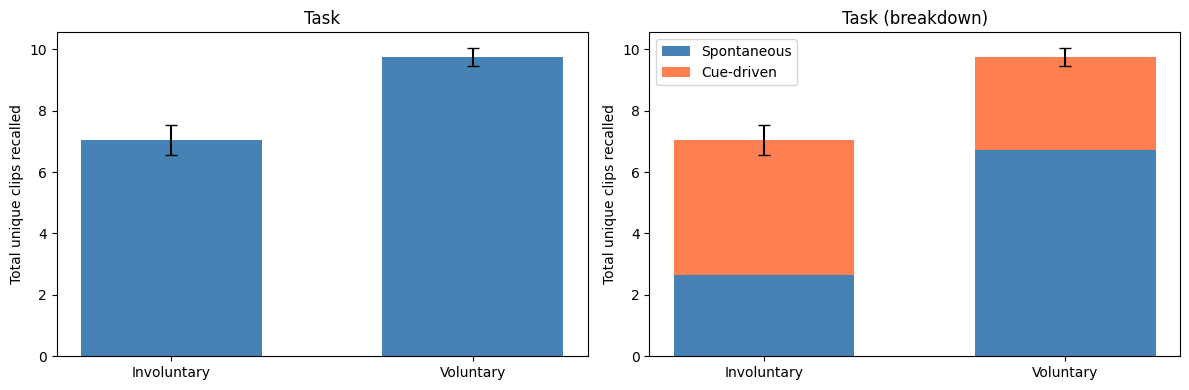

In [6]:
masks = [task == 1, task == 2]
labels = ["Involuntary", "Voluntary"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_total_recall(masks, labels, "Task", ax=axes[0])
plot_total_recall(masks, labels, "Task (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task")

## Condition (emotional vs neutral)

Emotional: n=120, mean=8.16 +/- 0.45
Neutral: n=120, mean=8.65 +/- 0.49
Emotional: n=120, total=8.16, spont=5.17, cued=2.99
Neutral: n=120, total=8.65, spont=4.22, cued=4.43


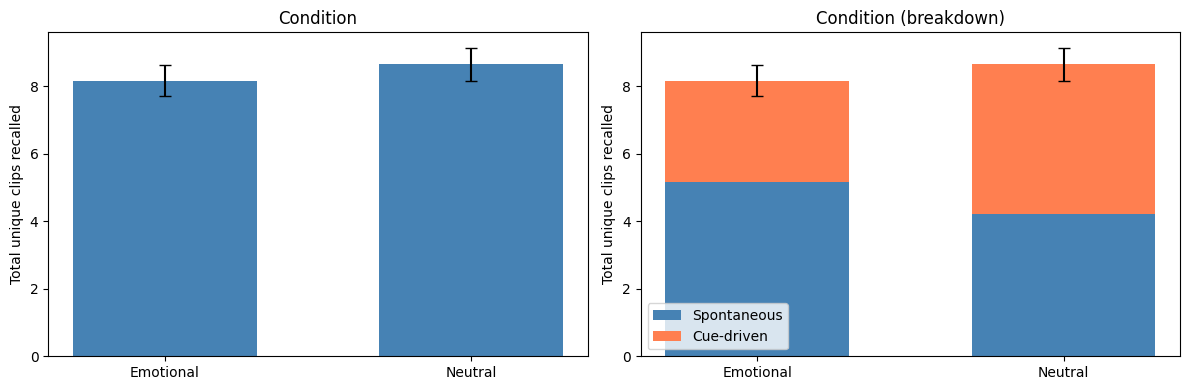

In [7]:
masks = [condition == 1, condition == 2]
labels = ["Emotional", "Neutral"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_total_recall(masks, labels, "Condition", ax=axes[0])
plot_total_recall(masks, labels, "Condition (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition")

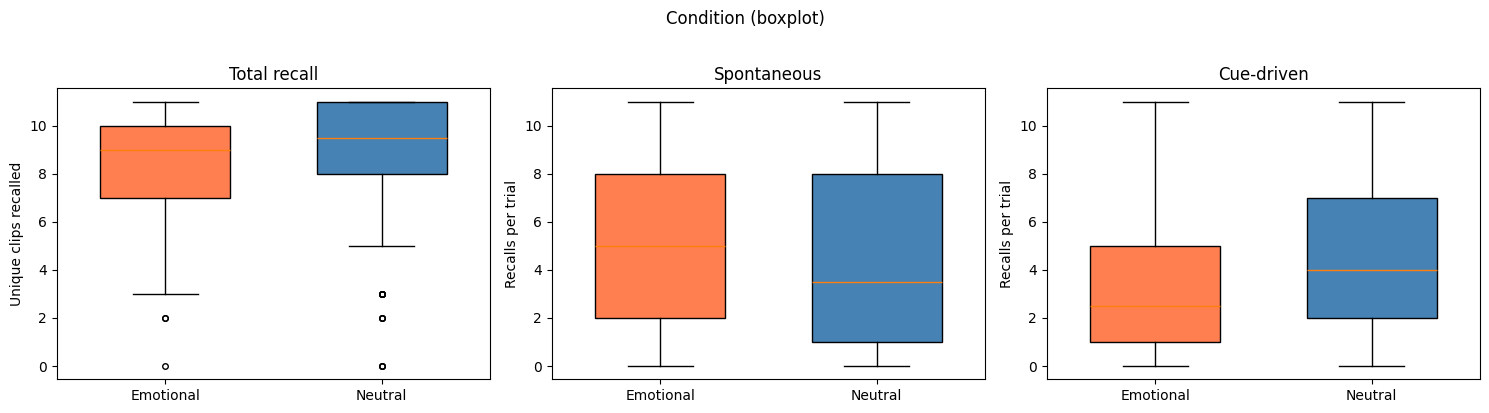

In [8]:
# Boxplot version: per-participant distributions by condition
def boxplot_by_condition(values, masks, labels, title, ylabel, ax):
    data = [subject_means(values, m, subjects) for m in masks]
    bp = ax.boxplot(data, widths=0.6, patch_artist=True,
                    flierprops=dict(marker='o', markersize=4))
    colors = ['coral', 'steelblue']
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

masks = [condition == 1, condition == 2]
labels = ['Emotional', 'Neutral']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
boxplot_by_condition(total, masks, labels, 'Total recall', 'Unique clips recalled', axes[0])
boxplot_by_condition(spontaneous, masks, labels, 'Spontaneous', 'Recalls per trial', axes[1])
boxplot_by_condition(cue_driven, masks, labels, 'Cue-driven', 'Recalls per trial', axes[2])
fig.suptitle('Condition (boxplot)', y=1.02)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix='condition_boxplot')


## Intervention (podcast vs Tetris)

Podcast: n=120, mean=8.48 +/- 0.46
Tetris: n=120, mean=8.32 +/- 0.49
Podcast: n=120, total=8.48, spont=4.74, cued=3.74
Tetris: n=120, total=8.32, spont=4.64, cued=3.68


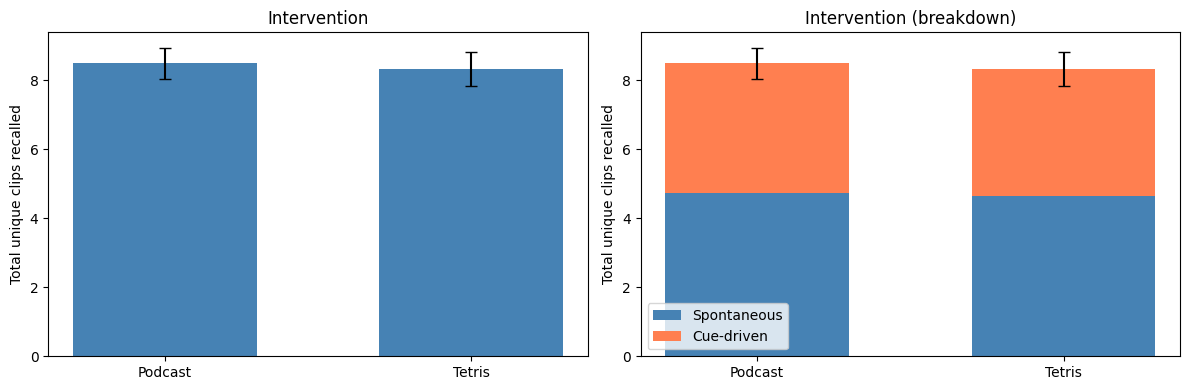

In [9]:
masks = [intervention == 0, intervention == 1]
labels = ["Podcast", "Tetris"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_total_recall(masks, labels, "Intervention", ax=axes[0])
plot_total_recall(masks, labels, "Intervention (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention")

## Task x Intervention

The selective interference hypothesis predicts that Tetris should reduce involuntary recall more than voluntary recall. This interaction is the critical test.

Invol+Podcast: n=60, mean=7.05 +/- 0.69
Invol+Tetris: n=60, mean=7.05 +/- 0.71
Vol+Podcast: n=60, mean=9.92 +/- 0.31
Vol+Tetris: n=60, mean=9.60 +/- 0.49
Invol+Podcast: n=60, total=7.05, spont=2.57, cued=4.48
Invol+Tetris: n=60, total=7.05, spont=2.75, cued=4.30
Vol+Podcast: n=60, total=9.92, spont=6.92, cued=3.00
Vol+Tetris: n=60, total=9.60, spont=6.53, cued=3.07


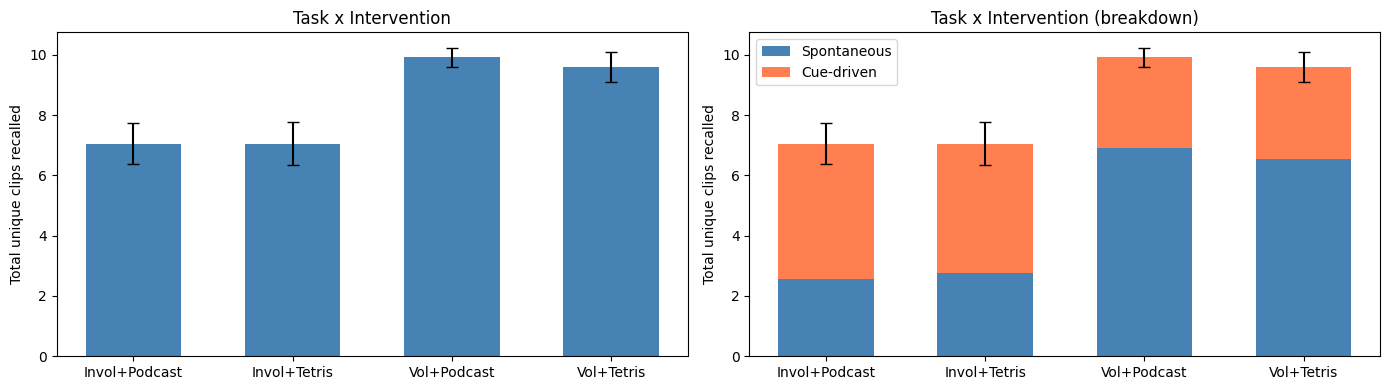

In [10]:
masks = [
    (task == 1) & (intervention == 0),
    (task == 1) & (intervention == 1),
    (task == 2) & (intervention == 0),
    (task == 2) & (intervention == 1),
]
labels = ["Invol+Podcast", "Invol+Tetris", "Vol+Podcast", "Vol+Tetris"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_total_recall(masks, labels, "Task x Intervention", ax=axes[0])
plot_total_recall(masks, labels, "Task x Intervention (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention")

## Task x Condition

Invol+Emot: n=60, mean=6.50 +/- 0.61
Invol+Neut: n=60, mean=7.60 +/- 0.75
Vol+Emot: n=60, mean=9.82 +/- 0.31
Vol+Neut: n=60, mean=9.70 +/- 0.49
Invol+Emot: n=60, total=6.50, spont=3.17, cued=3.33
Invol+Neut: n=60, total=7.60, spont=2.15, cued=5.45
Vol+Emot: n=60, total=9.82, spont=7.17, cued=2.65
Vol+Neut: n=60, total=9.70, spont=6.28, cued=3.42


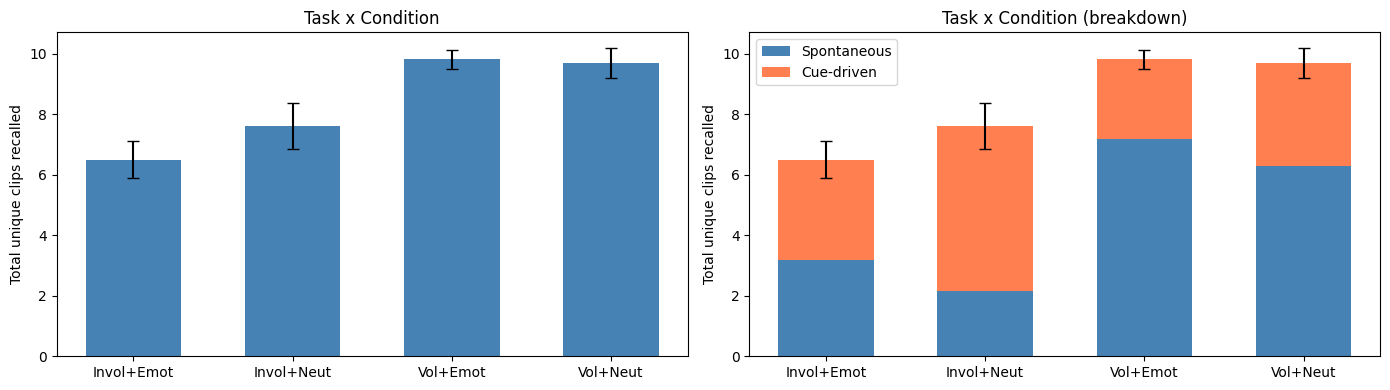

In [11]:
masks = [
    (task == 1) & (condition == 1),
    (task == 1) & (condition == 2),
    (task == 2) & (condition == 1),
    (task == 2) & (condition == 2),
]
labels = ["Invol+Emot", "Invol+Neut", "Vol+Emot", "Vol+Neut"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_total_recall(masks, labels, "Task x Condition", ax=axes[0])
plot_total_recall(masks, labels, "Task x Condition (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition")

## Condition x Intervention

Emot+Podcast: n=60, mean=8.13 +/- 0.69
Emot+Tetris: n=60, mean=8.18 +/- 0.60
Neut+Podcast: n=60, mean=8.83 +/- 0.59
Neut+Tetris: n=60, mean=8.47 +/- 0.78
Emot+Podcast: n=60, total=8.13, spont=5.32, cued=2.82
Emot+Tetris: n=60, total=8.18, spont=5.02, cued=3.17
Neut+Podcast: n=60, total=8.83, spont=4.17, cued=4.67
Neut+Tetris: n=60, total=8.47, spont=4.27, cued=4.20


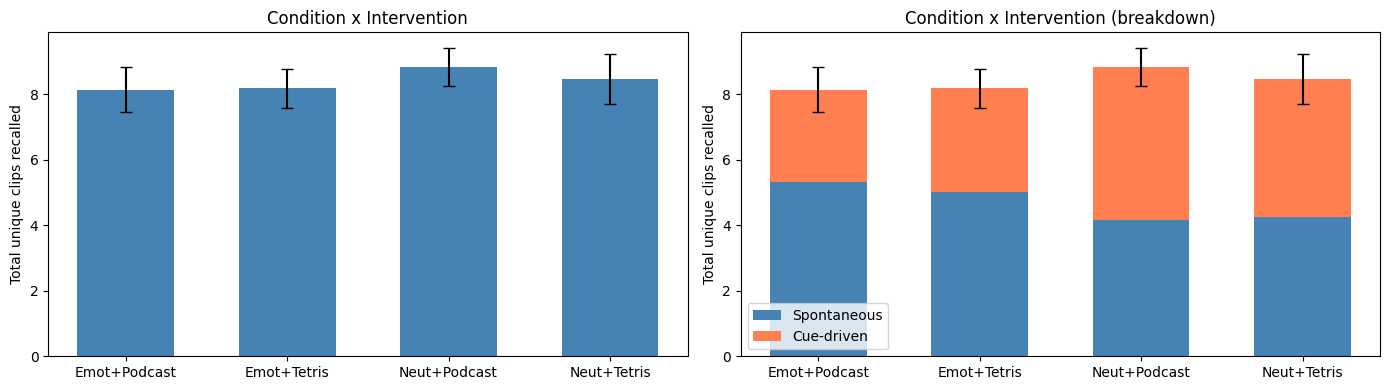

In [12]:
masks = [
    (condition == 1) & (intervention == 0),
    (condition == 1) & (intervention == 1),
    (condition == 2) & (intervention == 0),
    (condition == 2) & (intervention == 1),
]
labels = ["Emot+Podcast", "Emot+Tetris", "Neut+Podcast", "Neut+Tetris"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_total_recall(masks, labels, "Condition x Intervention", ax=axes[0])
plot_total_recall(masks, labels, "Condition x Intervention (breakdown)", breakdown=True, ax=axes[1])
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_intervention")

## Three-way: Task x Condition x Intervention

With ~30 subjects per cell, the three-way breakdown is viable for a scalar DV. This lets us check whether the selective interference pattern (Tetris reducing involuntary recall) is modulated by film emotionality.

Inv+Pod: n=30, total=6.20, spont=3.10, cued=3.10
Inv+Tet: n=30, total=6.80, spont=3.23, cued=3.57
Vol+Pod: n=30, total=10.07, spont=7.53, cued=2.53
Vol+Tet: n=30, total=9.57, spont=6.80, cued=2.77
Inv+Pod: n=30, total=7.90, spont=2.03, cued=5.87
Inv+Tet: n=30, total=7.30, spont=2.27, cued=5.03
Vol+Pod: n=30, total=9.77, spont=6.30, cued=3.47
Vol+Tet: n=30, total=9.63, spont=6.27, cued=3.37


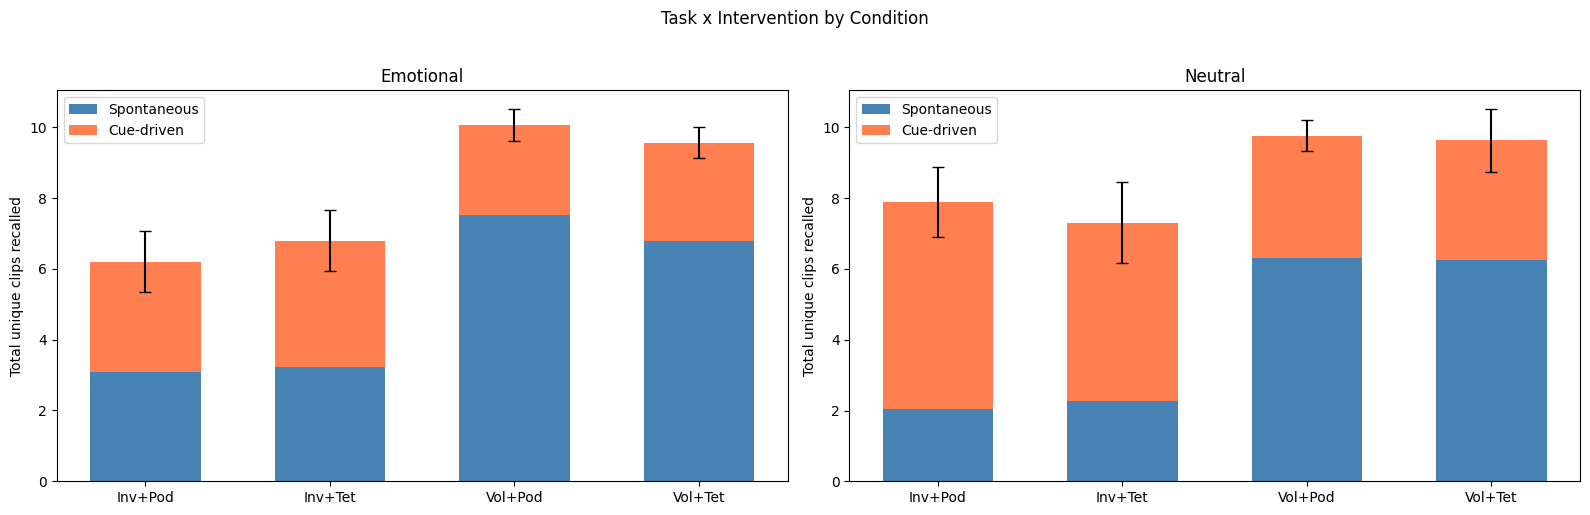

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Emotional film
masks_e = [
    (task == 1) & (condition == 1) & (intervention == 0),
    (task == 1) & (condition == 1) & (intervention == 1),
    (task == 2) & (condition == 1) & (intervention == 0),
    (task == 2) & (condition == 1) & (intervention == 1),
]
labels_e = ["Inv+Pod", "Inv+Tet", "Vol+Pod", "Vol+Tet"]
plot_total_recall(masks_e, labels_e, "Emotional", breakdown=True, ax=axes[0])

# Neutral film
masks_n = [
    (task == 1) & (condition == 2) & (intervention == 0),
    (task == 1) & (condition == 2) & (intervention == 1),
    (task == 2) & (condition == 2) & (intervention == 0),
    (task == 2) & (condition == 2) & (intervention == 1),
]
labels_n = ["Inv+Pod", "Inv+Tet", "Vol+Pod", "Vol+Tet"]
plot_total_recall(masks_n, labels_n, "Neutral", breakdown=True, ax=axes[1])

fig.suptitle("Task x Intervention by Condition", y=1.02)
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="three_way")